In [ ]:
# authors
# Nguyen Van A, ...

In [ ]:
# warning:
# only custmoze the 3-4-5 blocks

In [ ]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# input your data here
home = r'D:\Notebook\VNS'
COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

stk = 'MWG'
A = np.load(f"{home}/data/pv/{stk}.npy", allow_pickle=True)
P, V = A[:, 2], A[:, 6]

In [ ]:
# customize your prediction
def prediction(P, V, h=20):
    def truncate(u):
        v = u
        if v < -0.07:
            u = -0.07
        elif v > 0.07:
            u = 0.07
        return u
    n, L, Q = len(P), [], []
    for i in range(n):
        s, cnt = P[i], 1
        while (cnt <= h) and (i - cnt >= 0):
            s += P[i - cnt]
            cnt += 1
        L.append(s / cnt)
    for i in range(n):
        tmp = L[i] / P[i] - 1
        tmp = truncate(tmp)
        Q.append(tmp)
    return Q

In [ ]:
# keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i -1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1 :], t[1 :]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num


	base = 0.0  |  abs = 0.049  |  rel = -inf



C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\1433007368.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")


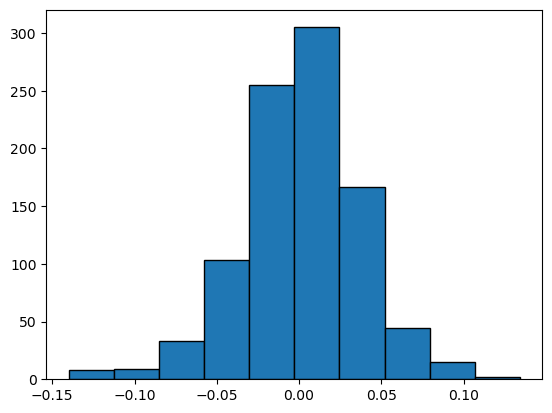

In [ ]:
# execute
# Note that score "rel" > 0 shows that there are good signals, "abs" < 0.005 is good signal
p, t = prediction(P, V, 5), target(P, V)
evaluate(p, t, True)

In [ ]:
def load_PV(stk, dint=[20240101, 20250101]):
    A = np.load(f"{home}/data/pv/{stk}.npy", allow_pickle=True)
    A = A[(A[:, 0] >= dint[0]) & (A[:, 0] < dint[1])]
    return A[:, 2], A[:, 6]

def get_ma(P, h=20):
    M, n = [], len(P)
    for i in range(n):
        tmp = i - h if i >= h else 0
        M.append(np.nanmean(P[tmp : i + 1]))
    return np.array(M)

def get_grw(P):
    return P / P[0] - 1

def get_acc(C, h=5):
    A, n = [], len(C)
    for i in range(n):
        tmp = i - h if i >= h else 0
        A.append(C[i] / C[tmp] - 1)
    return np.array(A)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3500164185.py:20: RuntimeWarning: invalid value encountered in scalar divide
  A.append(C[i] / C[tmp] - 1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3500164185.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  A.append(C[i] / C[tmp] - 1)


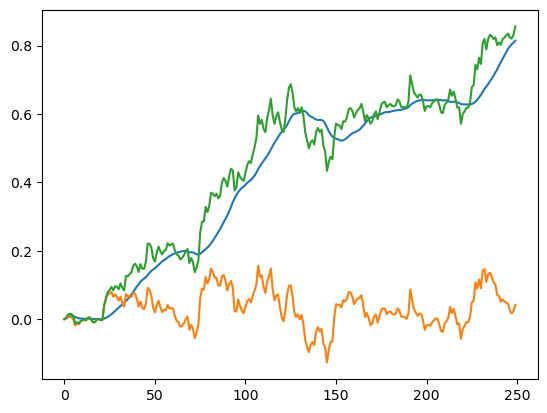

In [ ]:
stk = 'FPT'
P, V = load_PV(stk)
G = get_grw(P)
ma = get_ma(G)
diff = G - ma
acc = get_acc(ma)

plt.plot(np.arange(len(ma)), ma)
plt.plot(np.arange(len(diff)), diff)
plt.plot(np.arange(len(G)), G)
#plt.plot(np.arange(len(acc)), acc)
plt.show()

0.5809275054564906


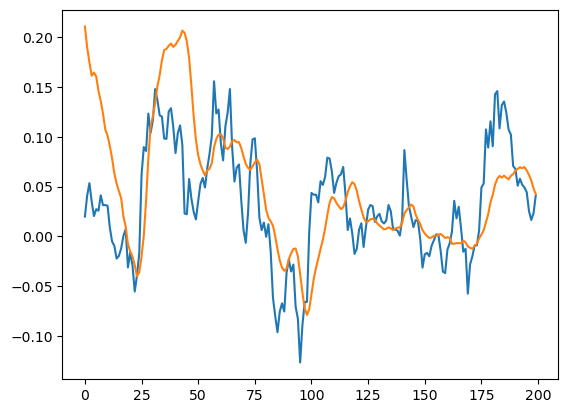

In [ ]:
X, Y = diff[50 :], acc[50 :]
print(np.corrcoef(X, Y)[0, 1])

plt.plot(np.arange(len(X)), X)
plt.plot(np.arange(len(Y)), Y)
plt.show()

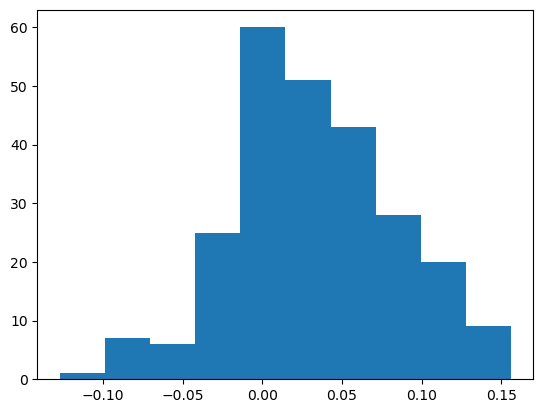

In [ ]:
plt.hist(diff)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3463677529.py:6: RuntimeWarning: invalid value encountered in power
  W = W**(0.25)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3463677529.py:8: RuntimeWarning: divide by zero encountered in divide
  rat = W / G
C:\Users\DELL\AppData\Local\Temp\ipykernel_11824\3463677529.py:8: RuntimeWarning: invalid value encountered in divide
  rat = W / G


0.7520234168202738


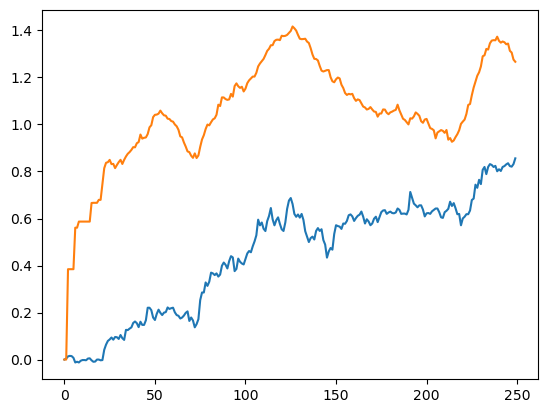

In [ ]:
stk = 'FPT'
P, V = load_PV(stk)

G = get_grw(P)
W = get_grw(V)
W = W**(0.25)
W = get_ma(W, 20)
rat = W / G

print(np.corrcoef(G, W)[0, 1])
plt.plot(np.arange(len(G)), G)
plt.plot(np.arange(len(W)), W)
#plt.plot(np.arange(len(rat)), rat)
plt.show()

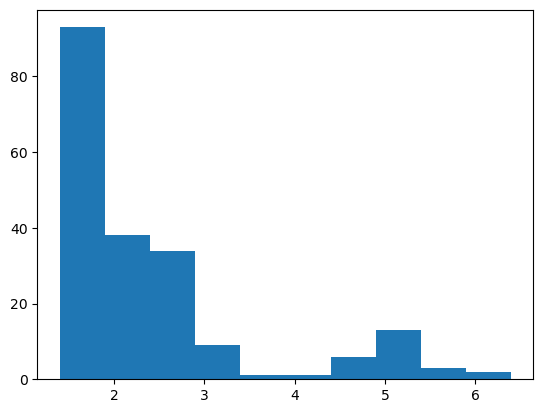

In [ ]:
plt.hist(rat[50 :])
plt.show()